# Data Collection

> Collect rollouts/episodes from the FindGoal env and save them to disk for later use in training and evaluation.

In [ ]:
#| default_exp data.collect

In [ ]:
#| hide
from nbdev.showdoc import *

In [ ]:
#| export
from fastcore import *
from fastcore.utils import *

In [1]:
#| hide
import numpy as np
rollouts = [np.load(f'../mains/data/rollouts/rollout_{i}.npz', allow_pickle=True) for i in range(10)]
list(rollouts[0].keys())

['episode_len',
 'success',
 'success_at',
 'agents_success_at',
 'seed',
 'policy',
 'layout',
 'goal_obs',
 'goal_pos',
 '0_img',
 '0_pov',
 '0_pos',
 '0_dir',
 '0_act',
 '0_rew',
 '0_csi',
 '1_img',
 '1_pov',
 '1_pos',
 '1_dir',
 '1_act',
 '1_rew',
 '1_csi']

In [2]:
[rollouts[i]['success'] for i in range(10) if 'success' in rollouts[i].keys()]

[array(True),
 array(True),
 array(True),
 array(False),
 array(True),
 array(True),
 array(True),
 array(True),
 array(True),
 array(True)]

In [3]:
[rollouts[i]['episode_len'] for i in range(10)]

[array(70),
 array(98),
 array(23),
 array(150),
 array(29),
 array(33),
 array(43),
 array(107),
 array(96),
 array(22)]

In [4]:
sum([rollouts[i]['episode_len'] for i in range(10)]) / 10

np.float64(67.1)

In [9]:
[rollouts[i]['policy'] for i in range(10)]

[array('epsilon_astar', dtype='<U13'),
 array('epsilon_astar', dtype='<U13'),
 array('epsilon_astar', dtype='<U13'),
 array('random', dtype='<U6'),
 array('waypoint', dtype='<U8'),
 array('waypoint', dtype='<U8'),
 array('epsilon_astar', dtype='<U13'),
 array('epsilon_astar', dtype='<U13'),
 array('epsilon_astar', dtype='<U13'),
 array('waypoint', dtype='<U8')]

In [5]:
rollouts[0]['1_csi'][:]

array([[[ 0.95968384+0.28108165j]],

       [[ 0.99984646-0.0175297j ]],

       [[ 0.99863553+0.0522223j ]],

       [[ 0.99759233-0.06935161j]],

       [[ 0.99759233-0.06935161j]],

       [[ 0.98657995+0.16327953j]],

       [[ 0.92639273+0.37655875j]],

       [[ 0.98467875+0.17437801j]],

       [[ 0.98467875+0.17437801j]],

       [[ 0.94789839+0.31857279j]],

       [[ 0.94789839+0.31857279j]],

       [[ 0.98235166+0.18704367j]],

       [[ 0.98235166+0.18704367j]],

       [[ 0.98676354+0.16216594j]],

       [[ 0.98676354+0.16216594j]],

       [[ 0.93841249+0.34551719j]],

       [[ 0.93841249+0.34551719j]],

       [[ 0.99042362+0.13806099j]],

       [[ 0.99042362+0.13806099j]],

       [[ 0.99042362+0.13806099j]],

       [[ 0.99042362+0.13806099j]],

       [[ 0.99042362+0.13806099j]],

       [[ 0.99042362+0.13806099j]],

       [[ 0.99042362+0.13806099j]],

       [[ 0.99042362+0.13806099j]],

       [[ 0.99042362+0.13806099j]],

       [[ 0.88673782-0.46227261j]],

 

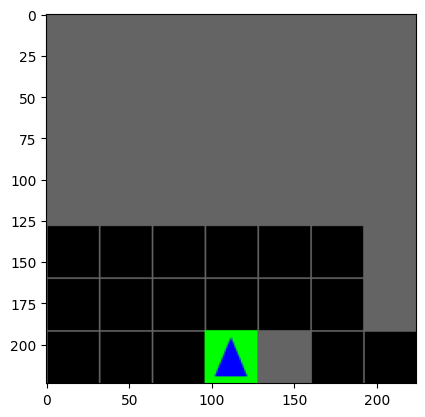

In [7]:
import matplotlib.pyplot as plt
plt.imshow(rollouts[0]['1_pov'][-1])
plt.show()

In [21]:
import h5py
file = "./exp/data/dataset.h5"
f = h5py.File(file, 'r')

In [22]:
list(f.keys())

['rollout_0',
 'rollout_1',
 'rollout_2',
 'rollout_3',
 'rollout_4',
 'rollout_5',
 'rollout_6',
 'rollout_7',
 'rollout_8',
 'rollout_9']

In [23]:
list(f['rollout_0'].attrs)

['episode_len', 'policy', 'seed', 'success', 'success_at']

In [33]:
f['rollout_0'].attrs['success_at']

np.int64(39)

In [30]:
rollout= f['rollout_0']
list(rollout.keys())

['0_act',
 '0_dir',
 '0_img',
 '0_pos',
 '0_pov',
 '0_rew',
 '1_act',
 '1_dir',
 '1_img',
 '1_pos',
 '1_pov',
 '1_rew',
 'goal_obs',
 'goal_pos',
 'layout']

In [38]:
actions = f['rollout_0/0_act']
actions.shape

(44,)

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()